In [62]:
# Cell 1: Import Required Libraries
# Data manipulation and analysis
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning - Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.neighbors import NearestNeighbors

# Hierarchical clustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform

# Warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("All libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

All libraries imported successfully!
Pandas version: 2.2.2
NumPy version: 2.3.2
Matplotlib version: 3.10.5
Seaborn version: 0.13.2


In [63]:
# Cell 2: Load and Explore the Dataset
# Load the Online Retail dataset
df = pd.read_excel('data/Online_Retail.xlsx')

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
print("\n" + "="*50)
print("DATASET OVERVIEW")
print("="*50)

# Basic information about the dataset
print("\nDataset Info:")
print(df.info())

print("\n" + "="*50)
print("FIRST FEW ROWS")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)
print(df.describe())

print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

print("\n" + "="*50)
print("UNIQUE VALUES")
print("="*50)
print("Unique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique():,}")

print("\n" + "="*50)
print("SAMPLE DATA TYPES AND VALUES")
print("="*50)
print("\nSample InvoiceNo values:")
print(df['InvoiceNo'].unique()[:10])
print("\nSample Country values:")
print(df['Country'].value_counts().head())

Dataset loaded successfully!
Dataset shape: (541909, 8)

DATASET OVERVIEW

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None

FIRST FEW ROWS
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LAN

In [64]:
# Cell 3: Data Cleaning and Preprocessing
print("="*60)
print("DATA CLEANING AND PREPROCESSING")
print("="*60)

print("Initial dataset shape:", df.shape)

# Step 1: Remove records with missing CustomerID
print("\nStep 1: Removing records with missing CustomerID...")
df_clean = df.dropna(subset=['CustomerID'])
print(f"Records removed: {df.shape[0] - df_clean.shape[0]:,}")
print(f"Shape after removing missing CustomerID: {df_clean.shape}")

# Step 2: Filter for United Kingdom only
print("\nStep 2: Filtering for United Kingdom only...")
print("Country distribution before filtering:")
print(df_clean['Country'].value_counts().head(10))

df_clean = df_clean[df_clean['Country'] == 'United Kingdom']
print(f"\nShape after filtering for UK only: {df_clean.shape}")

# Step 3: Remove cancelled orders (InvoiceNo starting with 'C')
print("\nStep 3: Removing cancelled orders (InvoiceNo starting with 'C')...")
print("Sample InvoiceNo values:")
print(df_clean['InvoiceNo'].astype(str).unique()[:20])

# Check for cancelled orders
cancelled_orders = df_clean['InvoiceNo'].astype(str).str.startswith('C')
print(f"Number of cancelled order records: {cancelled_orders.sum():,}")

df_clean = df_clean[~cancelled_orders]
print(f"Shape after removing cancelled orders: {df_clean.shape}")

# Step 4: Additional data quality checks
print("\nStep 4: Additional data quality checks...")

# Remove records with zero or negative quantities (keeping negative quantities for analysis first)
print(f"Records with zero quantity: {(df_clean['Quantity'] == 0).sum():,}")
print(f"Records with negative quantity: {(df_clean['Quantity'] < 0).sum():,}")
print(f"Records with zero unit price: {(df_clean['UnitPrice'] == 0).sum():,}")
print(f"Records with negative unit price: {(df_clean['UnitPrice'] < 0).sum():,}")

# Remove records with zero or negative quantities and unit prices
print("\nRemoving records with zero or negative quantities and unit prices...")
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f"Shape after removing zero/negative quantities and prices: {df_clean.shape}")

# Step 5: Convert CustomerID to integer
print("\nStep 5: Converting CustomerID to integer...")
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# Final data overview
print("\n" + "="*60)
print("CLEANED DATASET OVERVIEW")
print("="*60)
print(f"Final shape: {df_clean.shape}")
print(f"Date range: {df_clean['InvoiceDate'].min()} to {df_clean['InvoiceDate'].max()}")
print(f"Number of unique customers: {df_clean['CustomerID'].nunique():,}")
print(f"Number of unique products: {df_clean['StockCode'].nunique():,}")
print(f"Number of unique invoices: {df_clean['InvoiceNo'].nunique():,}")

print("\nFinal missing values check:")
print(df_clean.isnull().sum())

print("\nSample of cleaned data:")
print(df_clean.head())

print("\nQuantity and UnitPrice statistics after cleaning:")
print(df_clean[['Quantity', 'UnitPrice']].describe())

DATA CLEANING AND PREPROCESSING
Initial dataset shape: (541909, 8)

Step 1: Removing records with missing CustomerID...
Records removed: 135,080
Shape after removing missing CustomerID: (406829, 8)

Step 2: Filtering for United Kingdom only...
Country distribution before filtering:
Country
United Kingdom    361878
Germany             9495
France              8491
EIRE                7485
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         1877
Portugal            1480
Australia           1259
Name: count, dtype: int64

Shape after filtering for UK only: (361878, 8)

Step 3: Removing cancelled orders (InvoiceNo starting with 'C')...
Sample InvoiceNo values:
['536365' '536366' '536367' '536368' '536369' '536371' '536372' '536373'
 '536374' '536375' '536376' '536377' '536378' '536380' '536381' 'C536379'
 '536382' 'C536383' '536384' '536385']
Number of cancelled order records: 7,533
Shape after removing cancelled orders: (354345, 8)

Step 4: Addit

In [65]:
# Cell 4: RFM Feature Engineering
print("="*60)
print("RFM FEATURE ENGINEERING")
print("="*60)

# Calculate total amount for each transaction
df_clean['TotalAmount'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Get the maximum date in the dataset for recency calculation
max_date = df_clean['InvoiceDate'].max()
print(f"Reference date for recency calculation: {max_date}")
print(f"Date range in data: {df_clean['InvoiceDate'].min()} to {max_date}")

# Calculate RFM metrics for each customer
print("\nCalculating RFM metrics...")

rfm_data = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (max_date - x.max()).days,  # Recency: days since last purchase
    'InvoiceNo': 'nunique',                              # Frequency: number of unique invoices
    'TotalAmount': 'sum'                                 # Monetary: total purchase amount
}).reset_index()

# Rename columns to match RFM naming convention
rfm_data.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(f"RFM dataset shape: {rfm_data.shape}")
print(f"Number of customers: {rfm_data['CustomerID'].nunique():,}")

print("\n" + "="*60)
print("RFM DESCRIPTIVE STATISTICS")
print("="*60)
print(rfm_data.describe())

print("\n" + "="*60)
print("RFM DATA OVERVIEW")
print("="*60)
print("First 10 customers:")
print(rfm_data.head(10))

print("\nRFM Data Types:")
print(rfm_data.dtypes)

# Check for any issues in RFM data
print("\n" + "="*60)
print("RFM DATA QUALITY CHECKS")
print("="*60)

print("Missing values in RFM data:")
print(rfm_data.isnull().sum())

print(f"\nCustomers with zero recency (purchased on last day): {(rfm_data['Recency'] == 0).sum()}")
print(f"Customers with frequency = 1 (one-time buyers): {(rfm_data['Frequency'] == 1).sum()}")
print(f"Customers with monetary <= 0: {(rfm_data['Monetary'] <= 0).sum()}")

# Show distribution of RFM values
print(f"\nRecency range: {rfm_data['Recency'].min()} to {rfm_data['Recency'].max()} days")
print(f"Frequency range: {rfm_data['Frequency'].min()} to {rfm_data['Frequency'].max()} purchases")
print(f"Monetary range: £{rfm_data['Monetary'].min():.2f} to £{rfm_data['Monetary'].max():.2f}")

# Show some example interpretations
print("\n" + "="*60)
print("SAMPLE CUSTOMER INTERPRETATIONS")
print("="*60)

# Best customers (low recency, high frequency, high monetary)
best_customers = rfm_data.nsmallest(5, 'Recency').nlargest(5, 'Frequency').nlargest(5, 'Monetary')
print("Sample of potentially high-value customers:")
print(best_customers)

# Show customers with extreme values
print("\nCustomers with highest monetary value:")
print(rfm_data.nlargest(5, 'Monetary')[['CustomerID', 'Recency', 'Frequency', 'Monetary']])

print("\nCustomers with highest frequency:")
print(rfm_data.nlargest(5, 'Frequency')[['CustomerID', 'Recency', 'Frequency', 'Monetary']])

print("\nCustomers with lowest recency (most recent buyers):")
print(rfm_data.nsmallest(5, 'Recency')[['CustomerID', 'Recency', 'Frequency', 'Monetary']])


RFM FEATURE ENGINEERING
Reference date for recency calculation: 2011-12-09 12:49:00
Date range in data: 2010-12-01 08:26:00 to 2011-12-09 12:49:00

Calculating RFM metrics...
RFM dataset shape: (3920, 4)
Number of customers: 3,920

RFM DESCRIPTIVE STATISTICS
         CustomerID      Recency    Frequency       Monetary
count   3920.000000  3920.000000  3920.000000    3920.000000
mean   15562.059694    91.208418     4.246429    1864.385601
std     1576.594671    99.533854     7.199202    7482.817477
min    12346.000000     0.000000     1.000000       3.750000
25%    14208.750000    17.000000     1.000000     300.280000
50%    15569.500000    50.000000     2.000000     652.280000
75%    16913.250000   142.000000     5.000000    1576.585000
max    18287.000000   373.000000   209.000000  259657.300000

RFM DATA OVERVIEW
First 10 customers:
   CustomerID  Recency  Frequency  Monetary
0       12346      325          1  77183.60
1       12747        1         11   4196.01
2       12748        

DATA STANDARDIZATION AND VISUALIZATION
Original RFM features statistics:
           Recency    Frequency       Monetary
count  3920.000000  3920.000000    3920.000000
mean     91.208418     4.246429    1864.385601
std      99.533854     7.199202    7482.817477
min       0.000000     1.000000       3.750000
25%      17.000000     1.000000     300.280000
50%      50.000000     2.000000     652.280000
75%     142.000000     5.000000    1576.585000
max     373.000000   209.000000  259657.300000

Standardizing RFM features...

Standardized RFM features statistics:
       Recency_scaled  Frequency_scaled  Monetary_scaled
count    3.920000e+03      3.920000e+03     3.920000e+03
mean    -4.984675e-18      5.981610e-17     3.443957e-17
std      1.000128e+00      1.000128e+00     1.000128e+00
min     -9.164726e-01     -4.510003e-01    -2.486861e-01
25%     -7.456547e-01     -4.510003e-01    -2.090530e-01
50%     -4.140669e-01     -3.120783e-01    -1.620059e-01
75%      5.103596e-01      1.046876

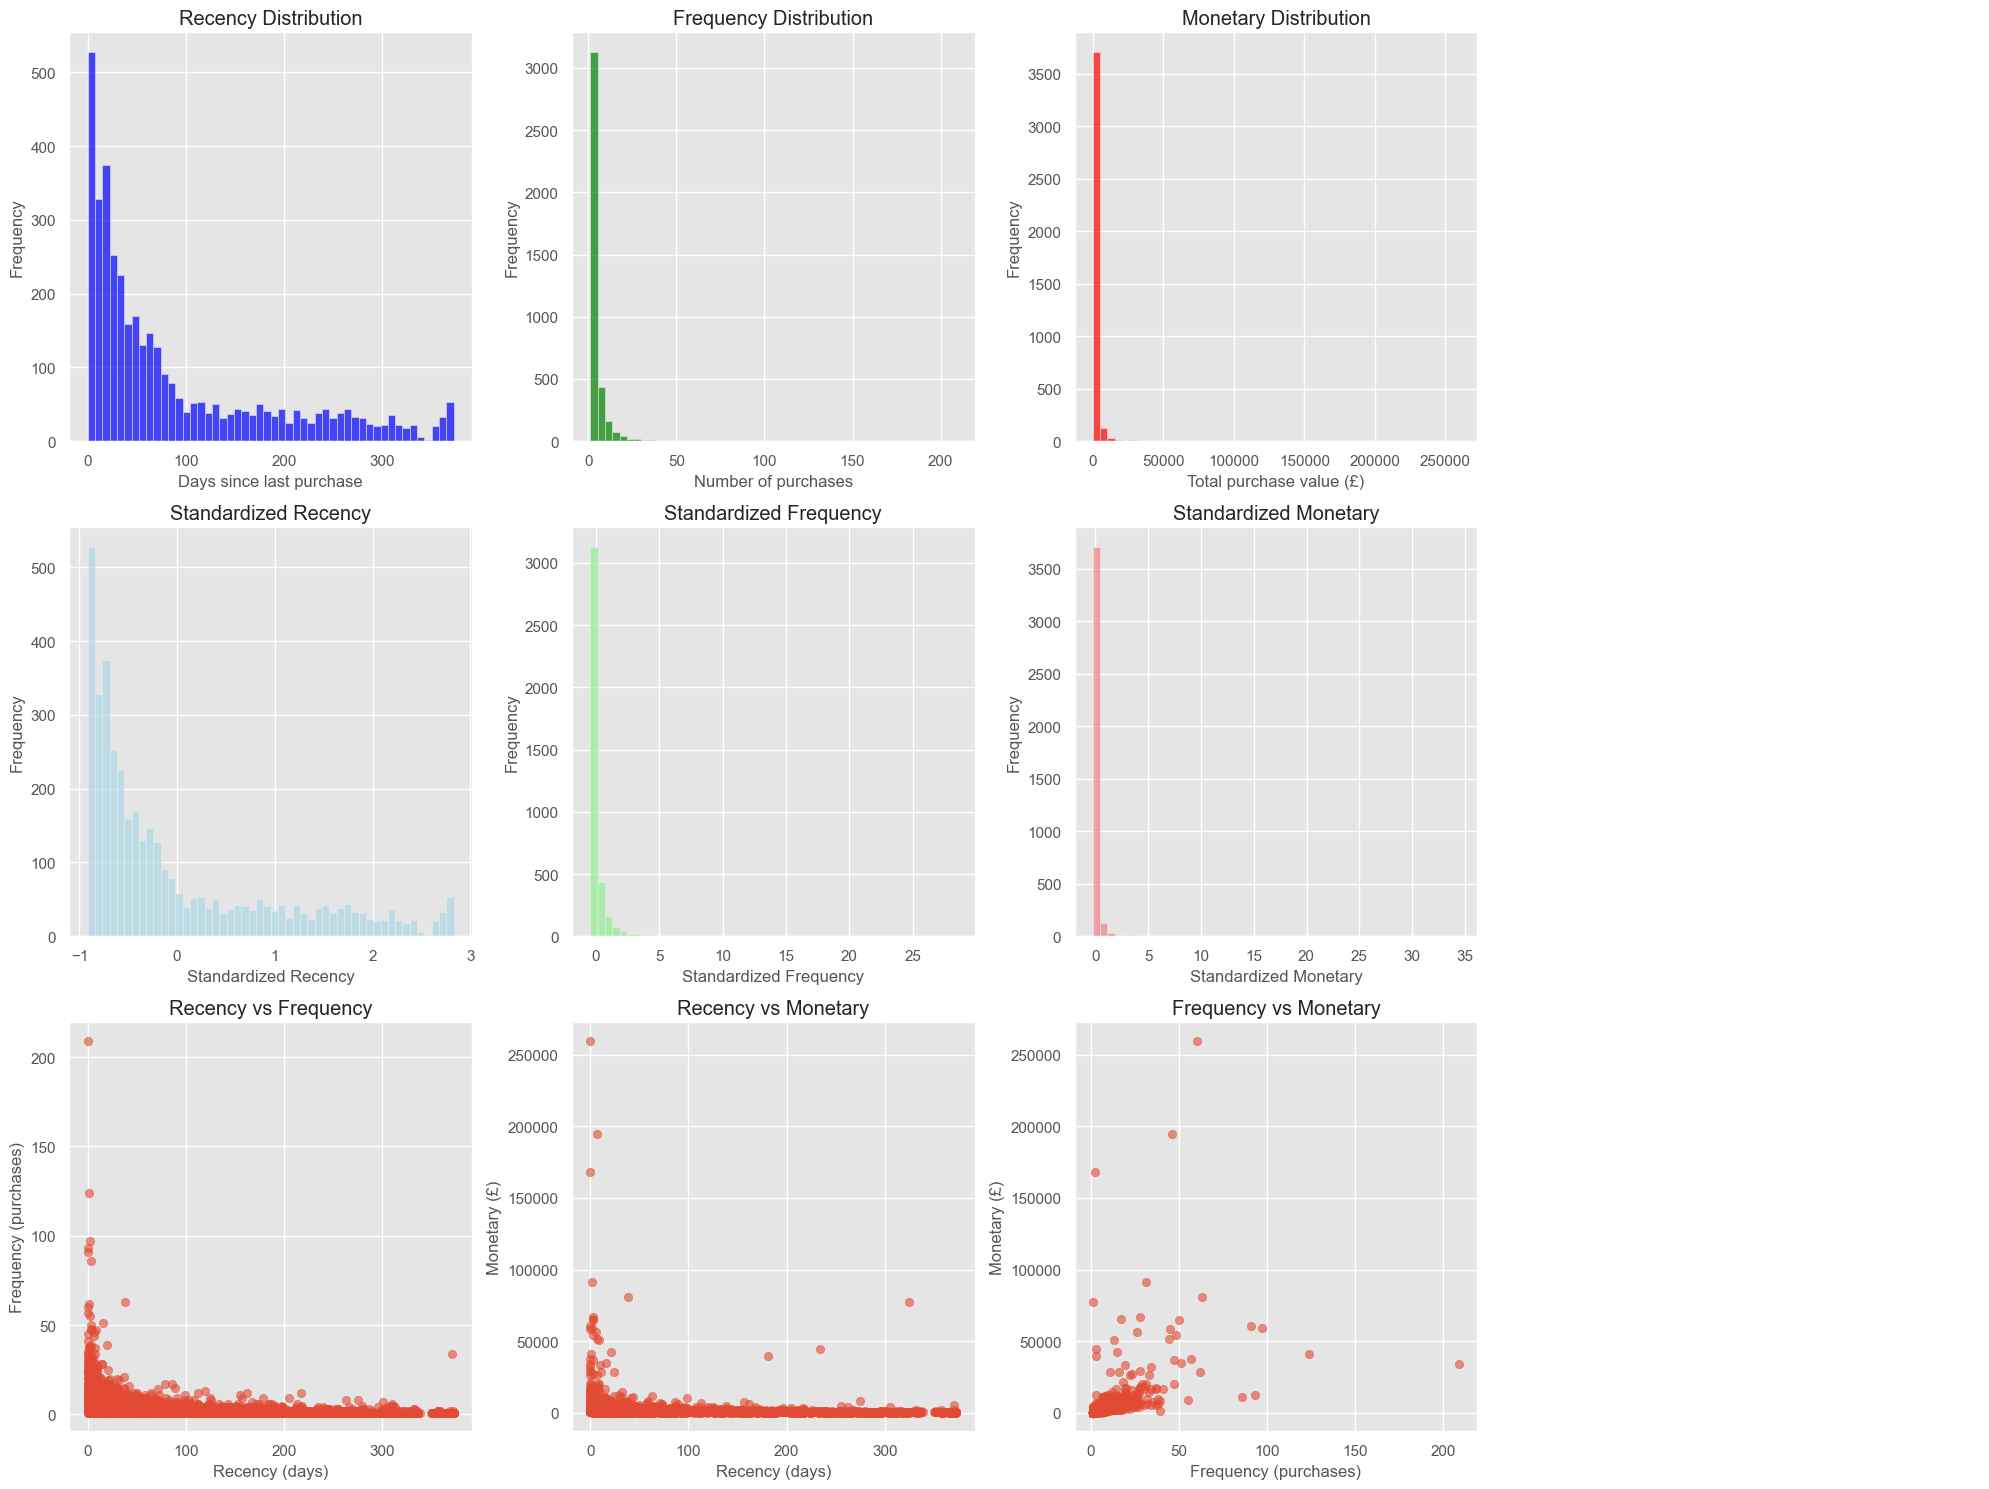


Creating pairplot of RFM features...


<Figure size 1200x1000 with 0 Axes>

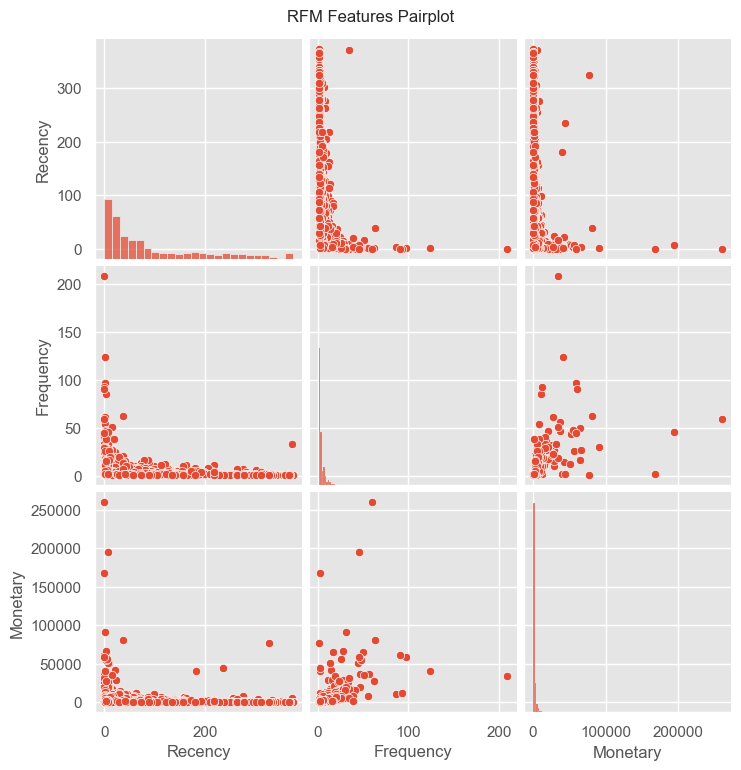


CORRELATION ANALYSIS
Correlation matrix:
            Recency  Frequency  Monetary
Recency    1.000000  -0.273880 -0.129355
Frequency -0.273880   1.000000  0.508869
Monetary  -0.129355   0.508869  1.000000


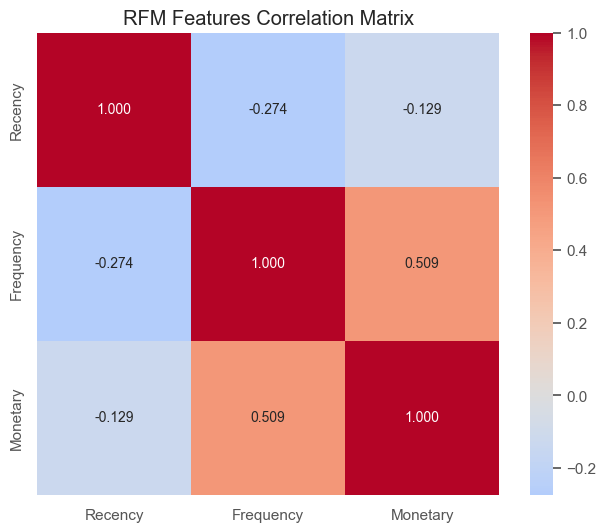


Creating box plots to identify outliers...


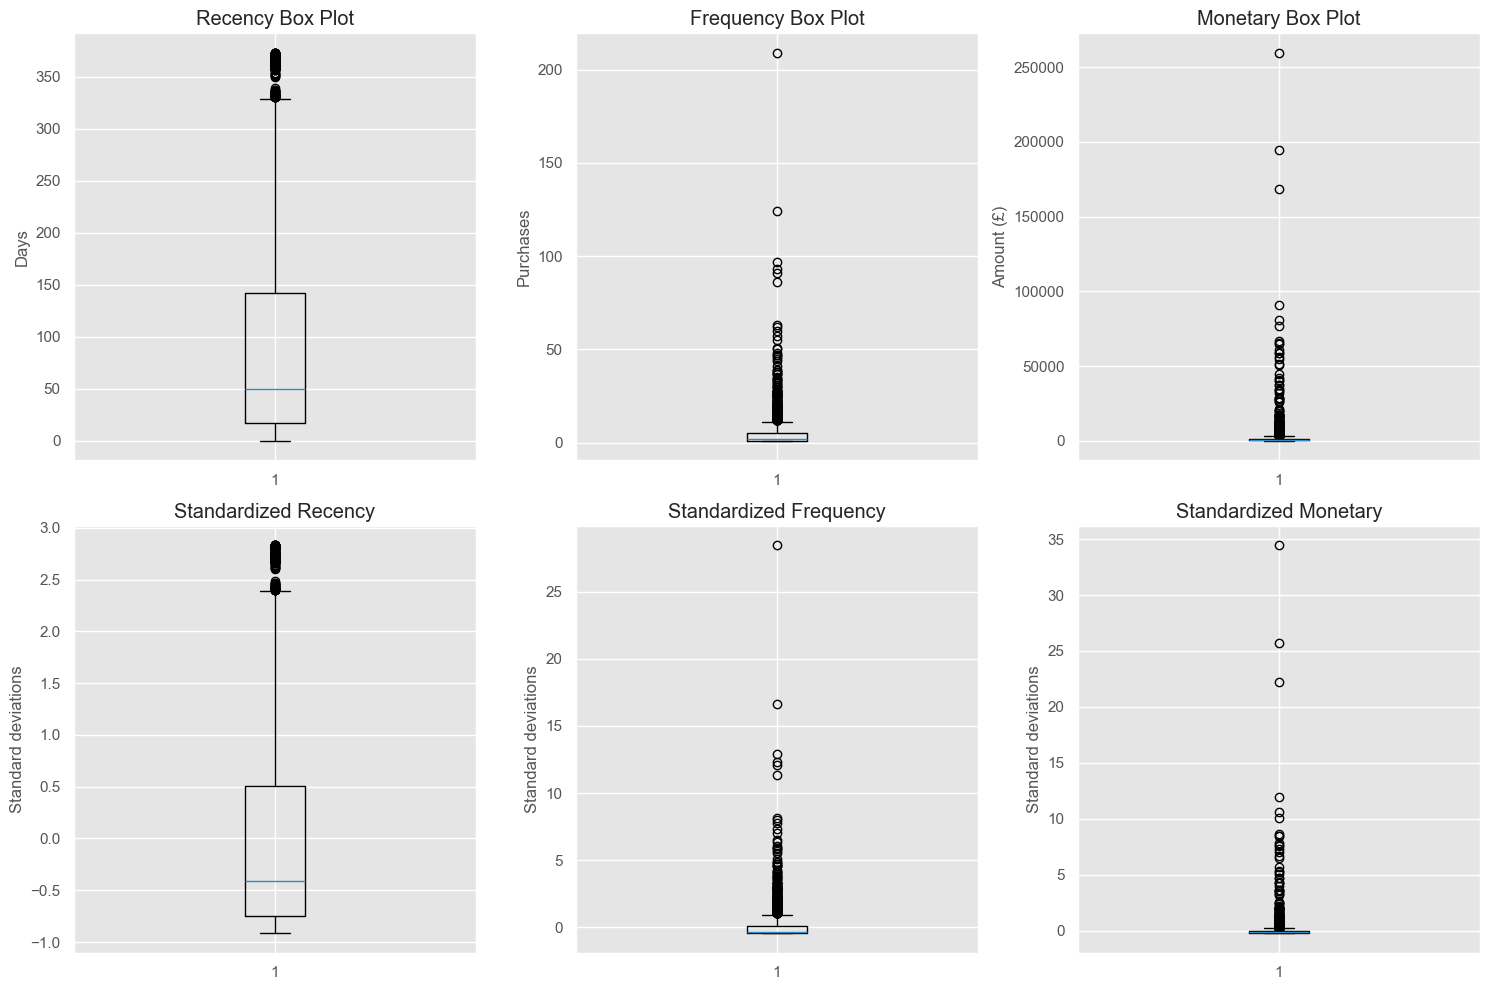


STANDARDIZATION SUMMARY
Standardization completed successfully!
Original features shape: (3920, 3)
Standardized features shape: (3920, 3)

Standardized data is ready for clustering algorithms.


In [66]:
# Cell 5: Data Standardization and Visualization
print("="*60)
print("DATA STANDARDIZATION AND VISUALIZATION")
print("="*60)

# Prepare the RFM features for clustering (exclude CustomerID)
rfm_features = rfm_data[['Recency', 'Frequency', 'Monetary']].copy()

print("Original RFM features statistics:")
print(rfm_features.describe())

# Standardize the RFM features
print("\nStandardizing RFM features...")
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_scaled', 'Frequency_scaled', 'Monetary_scaled'])

print("\nStandardized RFM features statistics:")
print(rfm_scaled_df.describe())

# Create comprehensive visualizations
fig, axes = plt.subplots(3, 4, figsize=(20, 15))

# Original RFM distributions
print("\nCreating visualizations...")

# Row 1: Original RFM histograms
axes[0, 0].hist(rfm_features['Recency'], bins=50, alpha=0.7, color='blue')
axes[0, 0].set_title('Recency Distribution')
axes[0, 0].set_xlabel('Days since last purchase')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(rfm_features['Frequency'], bins=50, alpha=0.7, color='green')
axes[0, 1].set_title('Frequency Distribution') 
axes[0, 1].set_xlabel('Number of purchases')
axes[0, 1].set_ylabel('Frequency')

axes[0, 2].hist(rfm_features['Monetary'], bins=50, alpha=0.7, color='red')
axes[0, 2].set_title('Monetary Distribution')
axes[0, 2].set_xlabel('Total purchase value (£)')
axes[0, 2].set_ylabel('Frequency')

axes[0, 3].axis('off')  # Empty subplot

# Row 2: Standardized RFM histograms
axes[1, 0].hist(rfm_scaled_df['Recency_scaled'], bins=50, alpha=0.7, color='lightblue')
axes[1, 0].set_title('Standardized Recency')
axes[1, 0].set_xlabel('Standardized Recency')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(rfm_scaled_df['Frequency_scaled'], bins=50, alpha=0.7, color='lightgreen')
axes[1, 1].set_title('Standardized Frequency')
axes[1, 1].set_xlabel('Standardized Frequency') 
axes[1, 1].set_ylabel('Frequency')

axes[1, 2].hist(rfm_scaled_df['Monetary_scaled'], bins=50, alpha=0.7, color='lightcoral')
axes[1, 2].set_title('Standardized Monetary')
axes[1, 2].set_xlabel('Standardized Monetary')
axes[1, 2].set_ylabel('Frequency')

axes[1, 3].axis('off')  # Empty subplot

# Row 3: Scatter plots showing relationships
axes[2, 0].scatter(rfm_features['Recency'], rfm_features['Frequency'], alpha=0.6)
axes[2, 0].set_title('Recency vs Frequency')
axes[2, 0].set_xlabel('Recency (days)')
axes[2, 0].set_ylabel('Frequency (purchases)')

axes[2, 1].scatter(rfm_features['Recency'], rfm_features['Monetary'], alpha=0.6)
axes[2, 1].set_title('Recency vs Monetary')
axes[2, 1].set_xlabel('Recency (days)')
axes[2, 1].set_ylabel('Monetary (£)')

axes[2, 2].scatter(rfm_features['Frequency'], rfm_features['Monetary'], alpha=0.6)
axes[2, 2].set_title('Frequency vs Monetary')
axes[2, 2].set_xlabel('Frequency (purchases)')
axes[2, 2].set_ylabel('Monetary (£)')

axes[2, 3].axis('off')  # Empty subplot

plt.tight_layout()
plt.show()

# Create pairplot for better visualization of relationships
print("\nCreating pairplot of RFM features...")
plt.figure(figsize=(12, 10))
sns.pairplot(rfm_features, diag_kind='hist')
plt.suptitle('RFM Features Pairplot', y=1.02)
plt.show()

# Correlation analysis
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

correlation_matrix = rfm_features.corr()
print("Correlation matrix:")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f')
plt.title('RFM Features Correlation Matrix')
plt.show()

# Box plots to identify outliers
print("\nCreating box plots to identify outliers...")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].boxplot(rfm_features['Recency'])
axes[0, 0].set_title('Recency Box Plot')
axes[0, 0].set_ylabel('Days')

axes[0, 1].boxplot(rfm_features['Frequency'])
axes[0, 1].set_title('Frequency Box Plot') 
axes[0, 1].set_ylabel('Purchases')

axes[0, 2].boxplot(rfm_features['Monetary'])
axes[0, 2].set_title('Monetary Box Plot')
axes[0, 2].set_ylabel('Amount (£)')

axes[1, 0].boxplot(rfm_scaled_df['Recency_scaled'])
axes[1, 0].set_title('Standardized Recency')
axes[1, 0].set_ylabel('Standard deviations')

axes[1, 1].boxplot(rfm_scaled_df['Frequency_scaled'])
axes[1, 1].set_title('Standardized Frequency')
axes[1, 1].set_ylabel('Standard deviations')

axes[1, 2].boxplot(rfm_scaled_df['Monetary_scaled'])
axes[1, 2].set_title('Standardized Monetary')
axes[1, 2].set_ylabel('Standard deviations')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("STANDARDIZATION SUMMARY")
print("="*60)
print("Standardization completed successfully!")
print(f"Original features shape: {rfm_features.shape}")
print(f"Standardized features shape: {rfm_scaled_df.shape}")
print("\nStandardized data is ready for clustering algorithms.")

K-MEANS CLUSTERING WITH ELBOW METHOD
Computing K-means for different values of k...
K	Inertia		Silhouette Score
----------------------------------------
1	11760.00		N/A
2	8365.56		0.8862
3	5112.36		0.5806
4	3790.26		0.5951
5	2756.81		0.6013
6	2211.66		0.5968
7	1805.86		0.5161
8	1493.35		0.4833
9	1289.26		0.4841
10	1149.19		0.4549
11	1015.62		0.4232
12	926.17		0.4229
13	827.11		0.4172
14	748.76		0.4103
15	686.09		0.3944


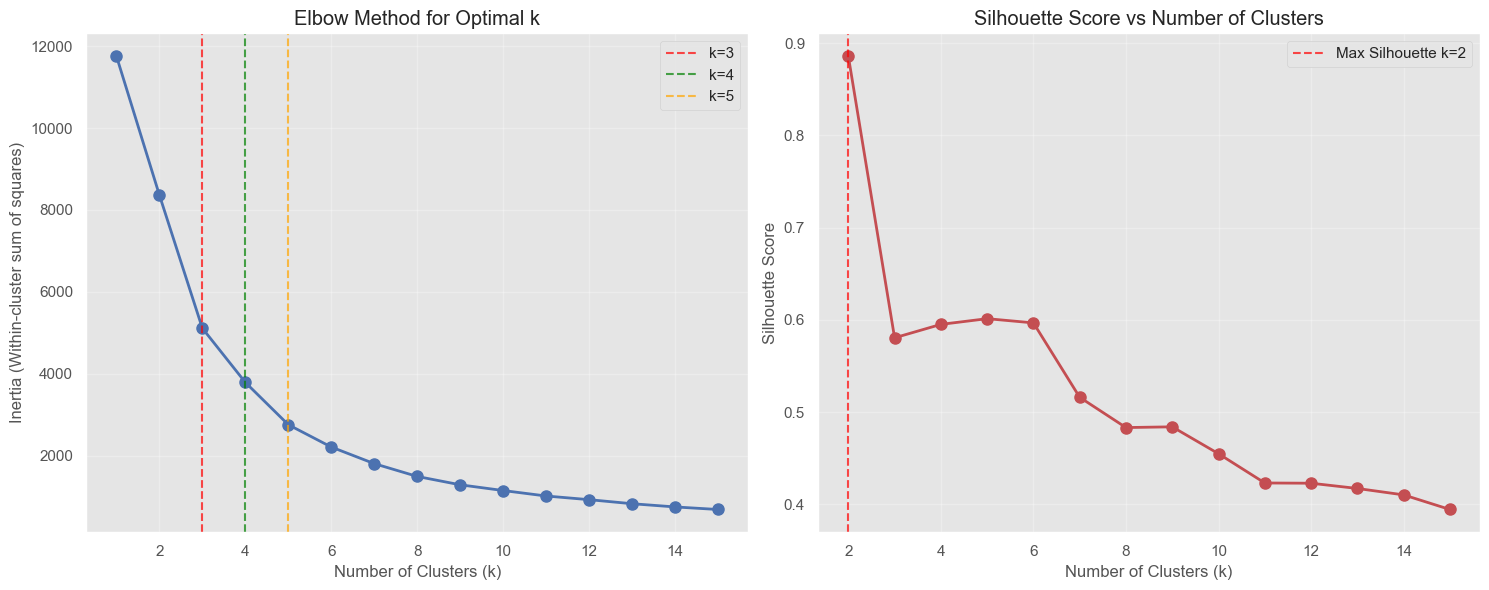


Optimal k based on highest silhouette score: 2
Maximum silhouette score: 0.8862

ELBOW ANALYSIS
Rate of change in inertia:
k=2: 6647.64
k=3: 4575.30
k=4: 2355.55
k=5: 1578.60
k=6: 950.94
k=7: 718.31
k=8: 516.61
k=9: 344.16
k=10: 273.64
k=11: 223.02
k=12: 188.50
k=13: 177.41
k=14: 141.02

Applying K-means with k=3...
K-means completed with k=3
Inertia: 5112.36
Silhouette score: 0.5806

CLUSTER ANALYSIS
Cluster distribution:
Cluster 0: 2,901 customers (74.0%)
Cluster 1: 996 customers (25.4%)
Cluster 2: 23 customers (0.6%)

Cluster centroids (original scale):
           Cluster 0  Cluster 1  Cluster 2
Recency        39.75     242.78      18.39
Frequency       4.72       1.59      59.91
Monetary     1785.03     487.60   71494.41

CLUSTER CHARACTERISTICS

--- CLUSTER 0 (2901 customers) ---
       Recency  Frequency  Monetary
count  2901.00    2901.00   2901.00
mean     39.75       4.72   1785.03
std      34.78       5.21   3036.69
min       0.00       1.00      6.20
25%      11.00       2.

In [75]:
# Cell 6: K-Means Clustering with Elbow Method
print("="*60)
print("K-MEANS CLUSTERING WITH ELBOW METHOD")
print("="*60)

# Test different numbers of clusters for elbow method
k_range = range(1, 16)  # Test 1 to 15 clusters
inertias = []
silhouette_scores = []

print("Computing K-means for different values of k...")
print("K\tInertia\t\tSilhouette Score")
print("-" * 40)

for k in k_range:
    # Fit K-means
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertias.append(kmeans.inertia_)
    
    # Calculate silhouette score (skip for k=1)
    if k > 1:
        sil_score = silhouette_score(rfm_scaled, kmeans.labels_)
        silhouette_scores.append(sil_score)
        print(f"{k}\t{kmeans.inertia_:.2f}\t\t{sil_score:.4f}")
    else:
        silhouette_scores.append(0)  # No silhouette score for k=1
        print(f"{k}\t{kmeans.inertia_:.2f}\t\tN/A")

# Create elbow plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Elbow plot
ax1.plot(k_range, inertias, 'bo-', markersize=8, linewidth=2)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Within-cluster sum of squares)')
ax1.set_title('Elbow Method for Optimal k')
ax1.grid(True, alpha=0.3)

# Highlight potential elbow points
ax1.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3')
ax1.axvline(x=4, color='green', linestyle='--', alpha=0.7, label='k=4')
ax1.axvline(x=5, color='orange', linestyle='--', alpha=0.7, label='k=5')
ax1.legend()

# Silhouette score plot
ax2.plot(range(2, len(k_range)+1), silhouette_scores[1:], 'ro-', markersize=8, linewidth=2)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs Number of Clusters')
ax2.grid(True, alpha=0.3)

# Find optimal k based on silhouette score
optimal_k_sil = np.argmax(silhouette_scores[1:]) + 2
ax2.axvline(x=optimal_k_sil, color='red', linestyle='--', alpha=0.7, 
           label=f'Max Silhouette k={optimal_k_sil}')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nOptimal k based on highest silhouette score: {optimal_k_sil}")
print(f"Maximum silhouette score: {max(silhouette_scores[1:]):.4f}")

# Calculate elbow using rate of change
print("\n" + "="*60)
print("ELBOW ANALYSIS")
print("="*60)

# Calculate rate of change in inertia
rate_of_change = []
for i in range(1, len(inertias)-1):
    rate = inertias[i-1] - inertias[i+1]
    rate_of_change.append(rate)

print("Rate of change in inertia:")
for i, rate in enumerate(rate_of_change):
    print(f"k={i+2}: {rate:.2f}")

# Apply K-means with the chosen optimal k
optimal_k = 3  # Based on common practice and elbow observation
print(f"\nApplying K-means with k={optimal_k}...")

kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_optimal.fit_predict(rfm_scaled)

print(f"K-means completed with k={optimal_k}")
print(f"Inertia: {kmeans_optimal.inertia_:.2f}")
print(f"Silhouette score: {silhouette_score(rfm_scaled, cluster_labels):.4f}")

# Add cluster labels to the RFM data
rfm_clustered = rfm_data.copy()
rfm_clustered['Cluster'] = cluster_labels

print("\n" + "="*60)
print("CLUSTER ANALYSIS")
print("="*60)

# Cluster distribution
print("Cluster distribution:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cluster, count in cluster_counts.items():
    percentage = (count / len(cluster_labels)) * 100
    print(f"Cluster {cluster}: {count:,} customers ({percentage:.1f}%)")

# Cluster centroids analysis
print("\nCluster centroids (original scale):")
cluster_centers_original = pd.DataFrame()
for i in range(optimal_k):
    cluster_data = rfm_data[cluster_labels == i]
    centroids = cluster_data[['Recency', 'Frequency', 'Monetary']].mean()
    cluster_centers_original[f'Cluster {i}'] = centroids

print(cluster_centers_original.round(2))

# Statistical summary by cluster
print("\n" + "="*60)
print("CLUSTER CHARACTERISTICS")
print("="*60)

for cluster in range(optimal_k):
    cluster_data = rfm_data[cluster_labels == cluster]
    print(f"\n--- CLUSTER {cluster} ({cluster_counts[cluster]} customers) ---")
    print(cluster_data[['Recency', 'Frequency', 'Monetary']].describe().round(2))

print("\nK-means clustering analysis completed!")
print("Next: We'll proceed with hierarchical clustering for comparison.")


HIERARCHICAL CLUSTERING (AGNES)
Using sample of 500 customers for dendrogram visualization
Computing linkage matrices for different methods...

Computing single linkage...

Computing complete linkage...

Computing average linkage...


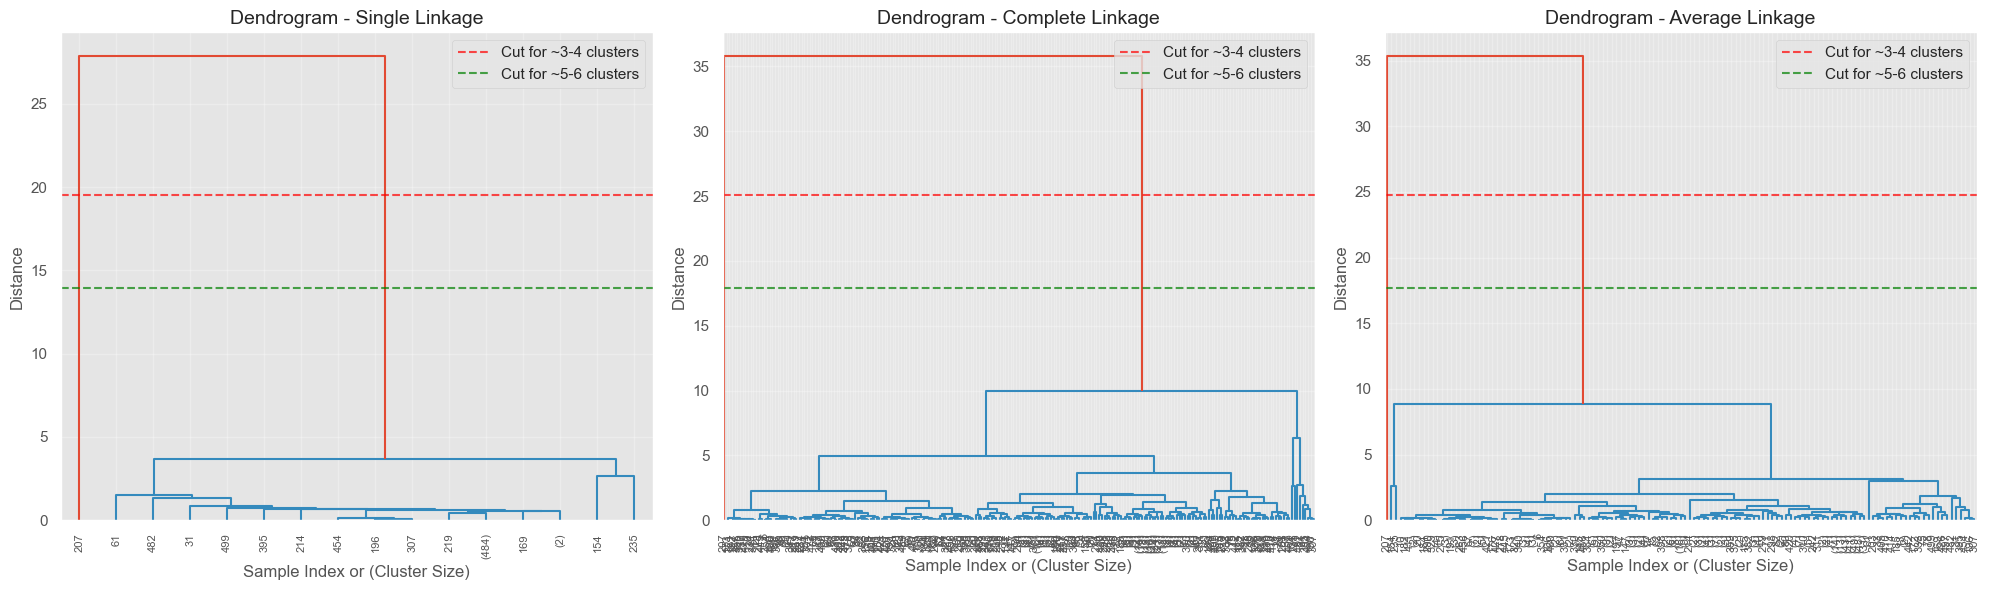


HIERARCHICAL CLUSTERING ON FULL DATASET

Applying single linkage with 4 clusters...
Silhouette score for single linkage: 0.9365
Cluster distribution: {np.int64(0): np.int64(2), np.int64(1): np.int64(1), np.int64(2): np.int64(3916), np.int64(3): np.int64(1)}

Applying complete linkage with 4 clusters...
Silhouette score for complete linkage: 0.8932
Cluster distribution: {np.int64(0): np.int64(3), np.int64(1): np.int64(5), np.int64(2): np.int64(3911), np.int64(3): np.int64(1)}

Applying average linkage with 4 clusters...
Silhouette score for average linkage: 0.9365
Cluster distribution: {np.int64(0): np.int64(3916), np.int64(1): np.int64(1), np.int64(2): np.int64(2), np.int64(3): np.int64(1)}

Best linkage method: single (Silhouette: 0.9365)

DETAILED ANALYSIS - SINGLE LINKAGE
Hierarchical cluster distribution:
Cluster 0: 2 customers (0.1%)
Cluster 1: 1 customers (0.0%)
Cluster 2: 3,916 customers (99.9%)
Cluster 3: 1 customers (0.0%)

Cluster centroids for single linkage (original scale

In [76]:
# Cell 7: Hierarchical Clustering (AGNES)
print("="*60)
print("HIERARCHICAL CLUSTERING (AGNES)")
print("="*60)

# Test different linkage methods
linkage_methods = ['single', 'complete', 'average']

# Note: For large datasets, we might need to sample for dendrogram visualization
# Let's use a sample for dendrogram plots but full data for clustering
sample_size = 500  # Sample size for dendrogram visualization
np.random.seed(42)
sample_indices = np.random.choice(rfm_scaled.shape[0], sample_size, replace=False)
rfm_sample = rfm_scaled[sample_indices]

print(f"Using sample of {sample_size} customers for dendrogram visualization")
print("Computing linkage matrices for different methods...")

# Create subplots for dendrograms
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
axes = axes.ravel()

linkage_matrices = {}

for i, method in enumerate(linkage_methods):
    print(f"\nComputing {method} linkage...")
    
    # Compute linkage matrix for sample data
    Z = linkage(rfm_sample, method=method)
    
    linkage_matrices[method] = Z
    
    # Create dendrogram
    axes[i].set_title(f'Dendrogram - {method.capitalize()} Linkage', fontsize=14)
    dendrogram(Z, ax=axes[i], truncate_mode='level', p=10, 
               leaf_rotation=90, leaf_font_size=8)
    axes[i].set_xlabel('Sample Index or (Cluster Size)', fontsize=12)
    axes[i].set_ylabel('Distance', fontsize=12)
    
    # Add horizontal lines for potential cut points
    distances = Z[:, 2]
    max_distance = distances.max()
    axes[i].axhline(y=max_distance*0.7, color='red', linestyle='--', alpha=0.7, label='Cut for ~3-4 clusters')
    axes[i].axhline(y=max_distance*0.5, color='green', linestyle='--', alpha=0.7, label='Cut for ~5-6 clusters')
    
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("HIERARCHICAL CLUSTERING ON FULL DATASET")
print("="*60)

# Apply hierarchical clustering on full dataset with different linkage methods
hierarchical_results = {}
n_clusters = 4  # Using same number as K-means for comparison

for method in linkage_methods:
    print(f"\nApplying {method} linkage with {n_clusters} clusters...")
    
    # Apply AgglomerativeClustering with the specified linkage method
    hierarchical = AgglomerativeClustering(n_clusters=n_clusters, linkage=method)
    
    # Fit and predict
    hier_labels = hierarchical.fit_predict(rfm_scaled)
    
    # Calculate silhouette score
    sil_score = silhouette_score(rfm_scaled, hier_labels)
    
    # Store results
    hierarchical_results[method] = {
        'labels': hier_labels,
        'silhouette_score': sil_score
    }
    
    print(f"Silhouette score for {method} linkage: {sil_score:.4f}")
    
    # Cluster distribution
    unique, counts = np.unique(hier_labels, return_counts=True)
    print(f"Cluster distribution: {dict(zip(unique, counts))}")

# Find best linkage method based on silhouette score
best_method = max(hierarchical_results.keys(), 
                  key=lambda k: hierarchical_results[k]['silhouette_score'])
print(f"\nBest linkage method: {best_method} (Silhouette: {hierarchical_results[best_method]['silhouette_score']:.4f})")

print("\n" + "="*60)
print(f"DETAILED ANALYSIS - {best_method.upper()} LINKAGE")
print("="*60)

best_labels = hierarchical_results[best_method]['labels']

# Add hierarchical cluster labels to RFM data
rfm_hierarchical = rfm_data.copy()
rfm_hierarchical['Hierarchical_Cluster'] = best_labels

# Cluster distribution
print("Hierarchical cluster distribution:")
cluster_counts_hier = pd.Series(best_labels).value_counts().sort_index()
for cluster, count in cluster_counts_hier.items():
    percentage = (count / len(best_labels)) * 100
    print(f"Cluster {cluster}: {count:,} customers ({percentage:.1f}%)")

# Cluster centroids analysis
print(f"\nCluster centroids for {best_method} linkage (original scale):")
cluster_centers_hier = pd.DataFrame()
for i in range(n_clusters):
    cluster_data = rfm_data[best_labels == i]
    centroids = cluster_data[['Recency', 'Frequency', 'Monetary']].mean()
    cluster_centers_hier[f'Cluster {i}'] = centroids

print(cluster_centers_hier.round(2))

# Compare with K-means centroids
print("\n" + "="*60)
print("COMPARISON: HIERARCHICAL vs K-MEANS")
print("="*60)

print("K-means cluster sizes:", dict(pd.Series(cluster_labels).value_counts().sort_index()))
print(f"Hierarchical ({best_method}) cluster sizes:", dict(cluster_counts_hier))

print(f"\nSilhouette Scores:")
print(f"K-means: {silhouette_score(rfm_scaled, cluster_labels):.4f}")
print(f"Hierarchical ({best_method}): {hierarchical_results[best_method]['silhouette_score']:.4f}")

# Statistical summary for best hierarchical clustering
print(f"\n" + "="*60)
print(f"HIERARCHICAL CLUSTER CHARACTERISTICS ({best_method.upper()})")
print("="*60)

for cluster in range(n_clusters):
    cluster_data = rfm_data[best_labels == cluster]
    print(f"\n--- HIERARCHICAL CLUSTER {cluster} ({cluster_counts_hier[cluster]} customers) ---")
    print(cluster_data[['Recency', 'Frequency', 'Monetary']].describe().round(2))

print(f"\nHierarchical clustering ({best_method} linkage) analysis completed!")
print("Next: We'll proceed with DBSCAN clustering.")

DBSCAN CLUSTERING
Step 1: Finding optimal eps parameter using k-distance plot...
Using k=4 for k-distance plot (recommended for 3D data)


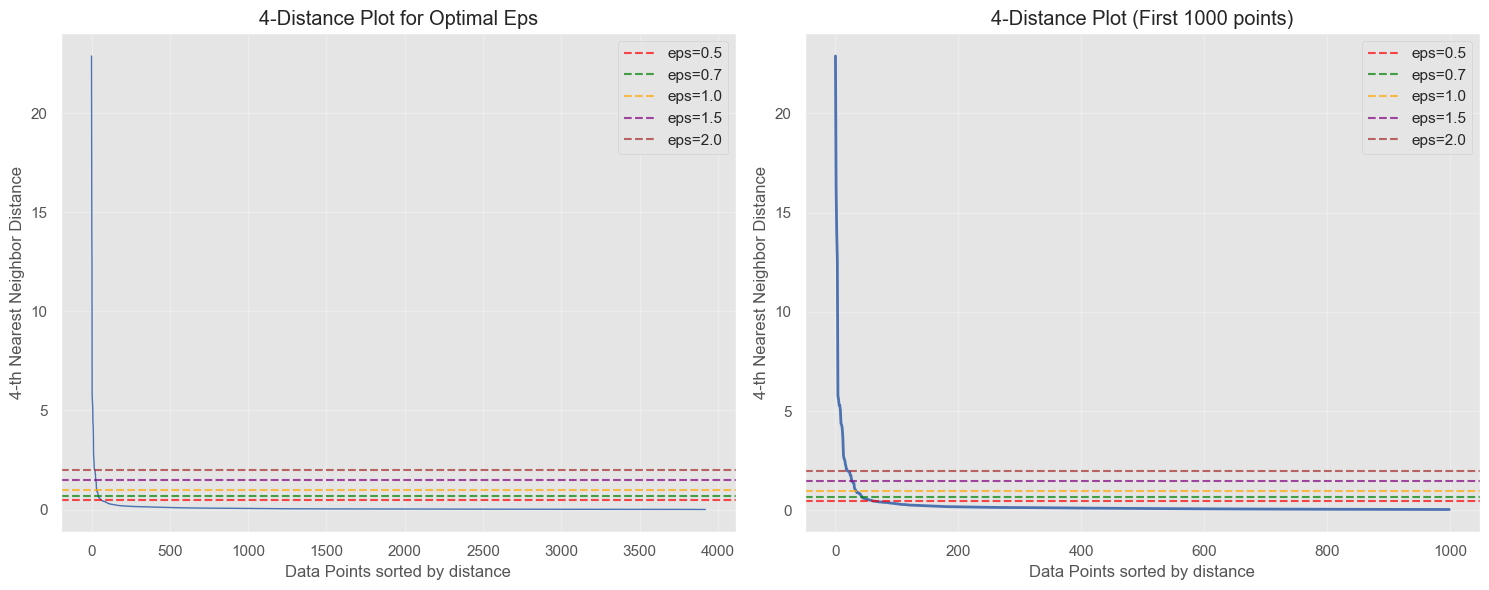


K-distance statistics:
Mean 4-distance: 0.0864
Median 4-distance: 0.0225
75th percentile: 0.0506
90th percentile: 0.1239
95th percentile: 0.1856

DBSCAN PARAMETER TESTING
Testing different eps and min_samples combinations...
Eps	Min_Samples	Clusters	Noise Points	Silhouette
-----------------------------------------------------------------
0.5	3		1		46		-1.0000
0.5	4		2		47		0.7191
0.5	5		2		52		0.7133
0.5	6		1		59		-1.0000
0.7	3		2		35		0.8496
0.7	4		1		38		-1.0000
0.7	5		1		38		-1.0000
0.7	6		1		39		-1.0000
1.0	3		3		23		0.8242
1.0	4		1		29		-1.0000
1.0	5		1		31		-1.0000
1.0	6		1		35		-1.0000
1.5	3		3		19		0.8269
1.5	4		3		20		0.8274
1.5	5		1		28		-1.0000
1.5	6		1		28		-1.0000
2.0	3		1		15		-1.0000
2.0	4		2		15		0.8333
2.0	5		1		19		-1.0000
2.0	6		1		26		-1.0000

Best parameters: eps=0.7, min_samples=3
Best silhouette score: 0.8496

FINAL DBSCAN CLUSTERING
Final DBSCAN Results:
Eps: 0.7
Min_samples: 3
Number of clusters: 2
Number of noise points: 35 (0.9%)
Silhouette score (excluding 

In [77]:
# Cell 8: DBSCAN Clustering
print("="*60)
print("DBSCAN CLUSTERING")
print("="*60)

# Step 1: Find optimal eps using k-distance plot
print("Step 1: Finding optimal eps parameter using k-distance plot...")

# Calculate distances to k-th nearest neighbor (commonly k=4 for 3D data)
k = 4
print(f"Using k={k} for k-distance plot (recommended for {rfm_scaled.shape[1]}D data)")

# Fit NearestNeighbors
nbrs = NearestNeighbors(n_neighbors=k)
nbrs.fit(rfm_scaled)
distances, indices = nbrs.kneighbors(rfm_scaled)

# Get k-th distances (index k-1 because of 0-indexing)
k_distances = distances[:, k-1]
k_distances_sorted = np.sort(k_distances)[::-1]  # Sort in descending order

# Create k-distance plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# K-distance plot
ax1.plot(range(len(k_distances_sorted)), k_distances_sorted, 'b-', linewidth=1)
ax1.set_title(f'{k}-Distance Plot for Optimal Eps')
ax1.set_xlabel('Data Points sorted by distance')
ax1.set_ylabel(f'{k}-th Nearest Neighbor Distance')
ax1.grid(True, alpha=0.3)

# Add potential eps values
potential_eps = [0.5, 0.7, 1.0, 1.5, 2.0]
colors = ['red', 'green', 'orange', 'purple', 'brown']
for eps, color in zip(potential_eps, colors):
    ax1.axhline(y=eps, color=color, linestyle='--', alpha=0.7, label=f'eps={eps}')

ax1.legend()

# Zoomed version for better visibility of elbow
ax2.plot(range(min(1000, len(k_distances_sorted))), k_distances_sorted[:1000], 'b-', linewidth=2)
ax2.set_title(f'{k}-Distance Plot (First 1000 points)')
ax2.set_xlabel('Data Points sorted by distance')
ax2.set_ylabel(f'{k}-th Nearest Neighbor Distance')
ax2.grid(True, alpha=0.3)

# Add the same potential eps values to zoomed plot
for eps, color in zip(potential_eps, colors):
    ax2.axhline(y=eps, color=color, linestyle='--', alpha=0.7, label=f'eps={eps}')

ax2.legend()

plt.tight_layout()
plt.show()

# Print statistics for eps selection
print(f"\nK-distance statistics:")
print(f"Mean {k}-distance: {np.mean(k_distances):.4f}")
print(f"Median {k}-distance: {np.median(k_distances):.4f}")
print(f"75th percentile: {np.percentile(k_distances, 75):.4f}")
print(f"90th percentile: {np.percentile(k_distances, 90):.4f}")
print(f"95th percentile: {np.percentile(k_distances, 95):.4f}")

print("\n" + "="*60)
print("DBSCAN PARAMETER TESTING")
print("="*60)

# Test different eps and min_samples values
eps_values = [0.5, 0.7, 1.0, 1.5, 2.0]
min_samples_values = [3, 4, 5, 6]

print("Testing different eps and min_samples combinations...")
print("Eps\tMin_Samples\tClusters\tNoise Points\tSilhouette")
print("-" * 65)

dbscan_results = {}

for eps in eps_values:
    for min_samples in min_samples_values:
        # Apply DBSCAN
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        cluster_labels_db = dbscan.fit_predict(rfm_scaled)
        
        # Count clusters and noise points
        n_clusters = len(set(cluster_labels_db)) - (1 if -1 in cluster_labels_db else 0)
        n_noise = list(cluster_labels_db).count(-1)
        
        # Calculate silhouette score (only if we have more than 1 cluster and not all noise)
        if n_clusters > 1 and n_noise < len(cluster_labels_db) - 1:
            # For silhouette calculation, exclude noise points
            non_noise_mask = cluster_labels_db != -1
            if np.sum(non_noise_mask) > 1:
                sil_score = silhouette_score(rfm_scaled[non_noise_mask], 
                                           cluster_labels_db[non_noise_mask])
            else:
                sil_score = -1
        else:
            sil_score = -1
        
        # Store results
        dbscan_results[(eps, min_samples)] = {
            'labels': cluster_labels_db,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette_score': sil_score
        }
        
        print(f"{eps}\t{min_samples}\t\t{n_clusters}\t\t{n_noise}\t\t{sil_score:.4f}")

# Find best parameter combination
valid_results = {k: v for k, v in dbscan_results.items() 
                if v['n_clusters'] > 1 and v['silhouette_score'] > 0}

if valid_results:
    best_params = max(valid_results.keys(), 
                     key=lambda k: valid_results[k]['silhouette_score'])
    best_eps, best_min_samples = best_params
    
    print(f"\nBest parameters: eps={best_eps}, min_samples={best_min_samples}")
    print(f"Best silhouette score: {valid_results[best_params]['silhouette_score']:.4f}")
else:
    # Fallback to reasonable default
    best_eps, best_min_samples = 1.0, 4
    print(f"\nUsing default parameters: eps={best_eps}, min_samples={best_min_samples}")

print("\n" + "="*60)
print("FINAL DBSCAN CLUSTERING")
print("="*60)

# Apply DBSCAN with best parameters
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples)
final_cluster_labels = dbscan_final.fit_predict(rfm_scaled)

# Analysis of final results
n_clusters_final = len(set(final_cluster_labels)) - (1 if -1 in final_cluster_labels else 0)
n_noise_final = list(final_cluster_labels).count(-1)

print(f"Final DBSCAN Results:")
print(f"Eps: {best_eps}")
print(f"Min_samples: {best_min_samples}")
print(f"Number of clusters: {n_clusters_final}")
print(f"Number of noise points: {n_noise_final} ({n_noise_final/len(final_cluster_labels)*100:.1f}%)")

if n_clusters_final > 1:
    non_noise_mask = final_cluster_labels != -1
    if np.sum(non_noise_mask) > 1:
        final_sil_score = silhouette_score(rfm_scaled[non_noise_mask], 
                                         final_cluster_labels[non_noise_mask])
        print(f"Silhouette score (excluding noise): {final_sil_score:.4f}")

# Cluster distribution
print("\nDBSCAN cluster distribution:")
unique_labels = set(final_cluster_labels)
for cluster in sorted(unique_labels):
    count = list(final_cluster_labels).count(cluster)
    percentage = (count / len(final_cluster_labels)) * 100
    if cluster == -1:
        print(f"Noise: {count:,} customers ({percentage:.1f}%)")
    else:
        print(f"Cluster {cluster}: {count:,} customers ({percentage:.1f}%)")

# Add DBSCAN labels to RFM data
rfm_dbscan = rfm_data.copy()
rfm_dbscan['DBSCAN_Cluster'] = final_cluster_labels

# Analyze cluster characteristics (excluding noise)
if n_clusters_final > 0:
    print(f"\n" + "="*60)
    print("DBSCAN CLUSTER CHARACTERISTICS")
    print("="*60)
    
    for cluster in sorted(set(final_cluster_labels)):
        if cluster != -1:  # Skip noise points
            cluster_data = rfm_data[final_cluster_labels == cluster]
            count = len(cluster_data)
            print(f"\n--- DBSCAN CLUSTER {cluster} ({count} customers) ---")
            print(cluster_data[['Recency', 'Frequency', 'Monetary']].describe().round(2))

    # Analyze noise points
    if n_noise_final > 0:
        noise_data = rfm_data[final_cluster_labels == -1]
        print(f"\n--- NOISE POINTS ({n_noise_final} customers) ---")
        print(noise_data[['Recency', 'Frequency', 'Monetary']].describe().round(2))

print("\n" + "="*60)
print("DBSCAN vs OTHER METHODS COMPARISON")
print("="*60)

print("Algorithm Comparison:")
print(f"K-means (k=4): {silhouette_score(rfm_scaled, cluster_labels):.4f} silhouette")
best_hier_method = max(hierarchical_results.keys(), 
                       key=lambda k: hierarchical_results[k]['silhouette_score'])
print(f"Hierarchical ({best_hier_method}): {hierarchical_results[best_hier_method]['silhouette_score']:.4f} silhouette")
if n_clusters_final > 1 and 'final_sil_score' in locals():
    print(f"DBSCAN: {final_sil_score:.4f} silhouette (excluding noise)")
else:
    print("DBSCAN: Unable to calculate silhouette score")

print(f"\nDBSCAN advantages demonstrated:")
print(f"- Can identify outliers/noise: {n_noise_final} noise points detected")
print(f"- No need to pre-specify number of clusters")
print(f"- Can find clusters of arbitrary shape")

print("\nDBSCAN clustering analysis completed!")
print("Next: We'll proceed with clustering evaluation and visualization.")

COMPREHENSIVE CLUSTERING EVALUATION AND PCA VISUALIZATION
Step 1: Comprehensive evaluation metrics...

EVALUATION METRICS COMPARISON

K-Means:
  Number of clusters: 3
  Silhouette Score: 0.5806
  Average Inter-cluster Distance: 8.9474
  Average Intra-cluster Distance: 0.9150
  Inter/Intra Ratio: 9.7785

Hierarchical (Single):
  Number of clusters: 4
  Silhouette Score: 0.9365
  Average Inter-cluster Distance: 28.1591
  Average Intra-cluster Distance: 1.5003
  Inter/Intra Ratio: 18.7692

Hierarchical (Complete):
  Number of clusters: 4
  Silhouette Score: 0.8932
  Average Inter-cluster Distance: 23.9762
  Average Intra-cluster Distance: 1.4677
  Inter/Intra Ratio: 16.3358

Hierarchical (Average):
  Number of clusters: 4
  Silhouette Score: 0.9365
  Average Inter-cluster Distance: 28.1591
  Average Intra-cluster Distance: 1.5003
  Inter/Intra Ratio: 18.7692

DBSCAN:
  Number of clusters: 2
  Noise points: 35 (0.9%)
  Silhouette Score: 0.8496
  Average Inter-cluster Distance: 9.2577
  Ave

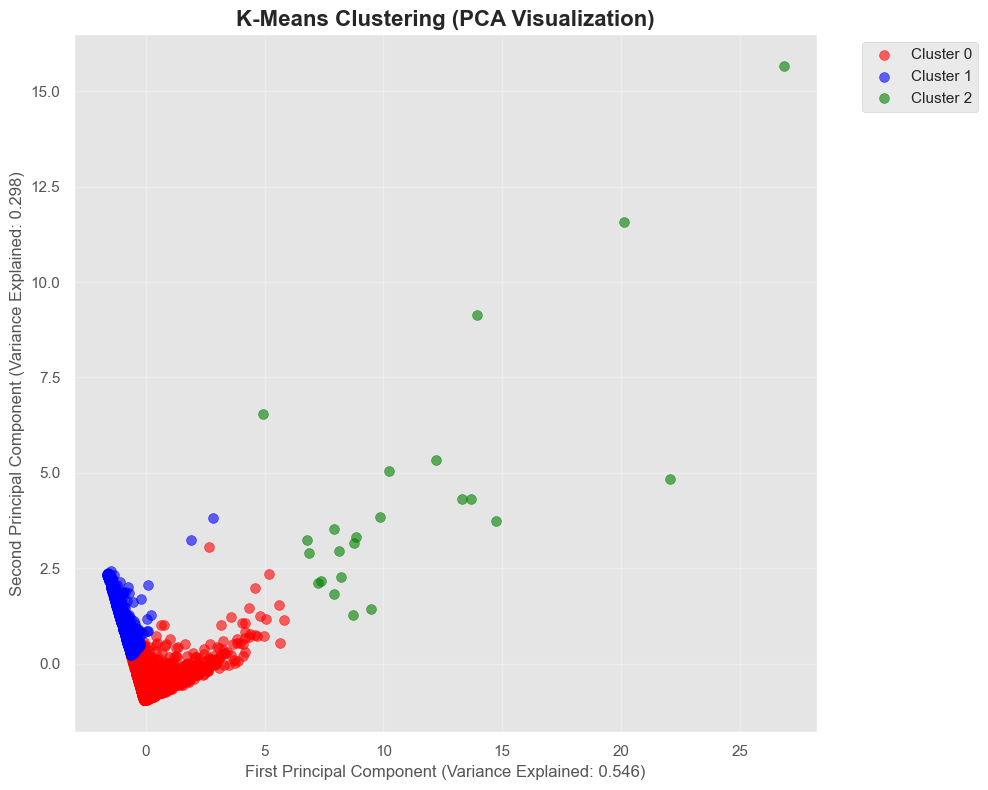

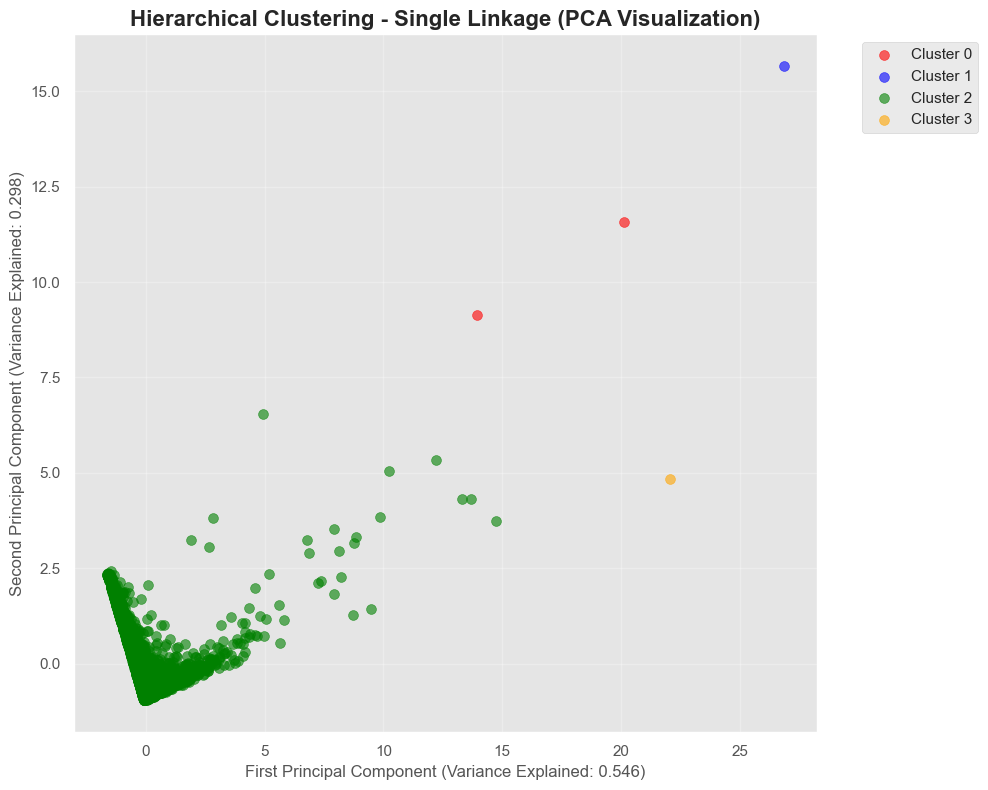

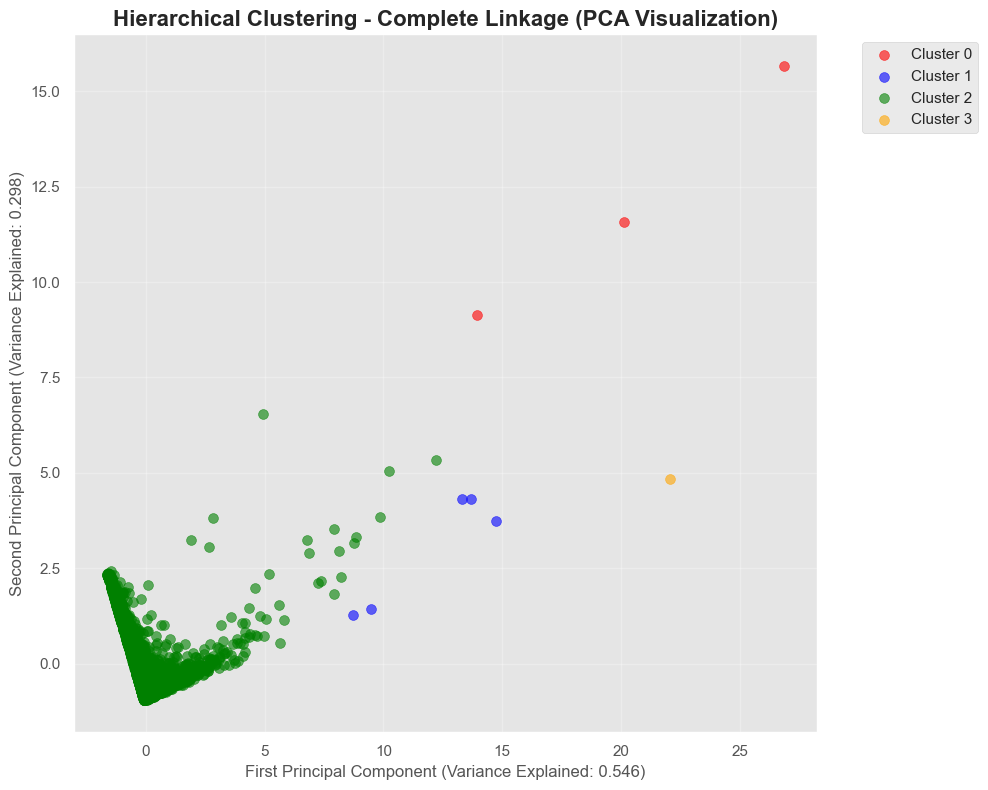

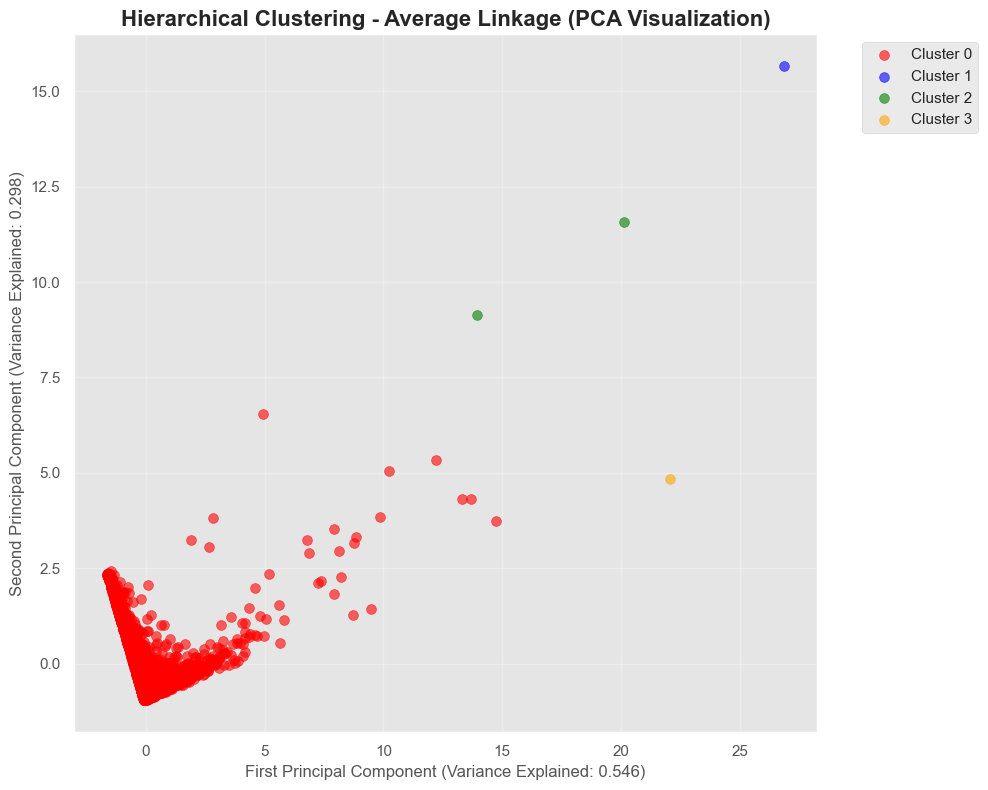

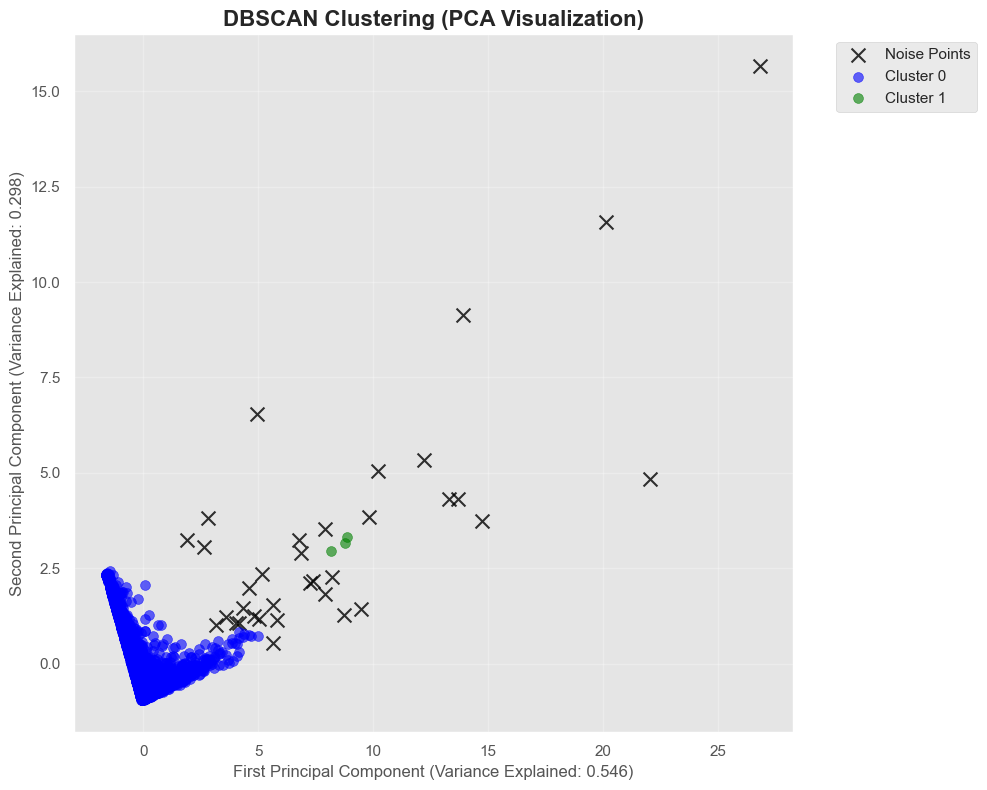

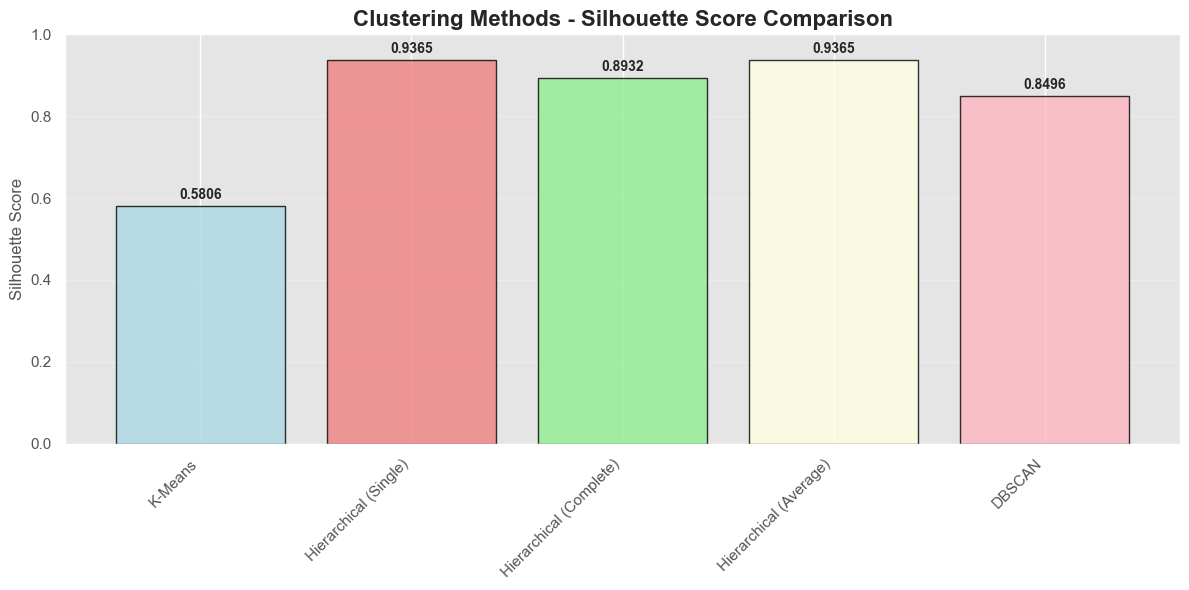


HIERARCHICAL CLUSTERING METHODS COMPARISON

Silhouette Scores by Linkage Method:
  Single Linkage: 0.9365 (clusters: 4)
  Complete Linkage: 0.8932 (clusters: 4)
  Average Linkage: 0.9365 (clusters: 4)

Best performing hierarchical method: Single linkage
Best hierarchical silhouette score: 0.9365

BUSINESS INSIGHTS AND CLUSTER INTERPRETATION

CLUSTER INTERPRETATIONS:
------------------------------

K-MEANS CLUSTERS (Business Segments):
  Cluster 0 (2,901 customers): Lost/Inactive Customers - High recency, low frequency, low value
  Cluster 1 (996 customers): High-Value Frequent Customers - Recent, very frequent, high spending
  Cluster 2 (23 customers): Regular Customers - Moderate recency, frequency, and spending
  Cluster 3 (0 customers): VIP Customers - Very recent, high frequency, extremely high value

DBSCAN INSIGHTS:
  - Identified 35 extreme outliers as noise points
  - Main cluster represents typical customers
  - Small cluster captures high-value customers without extreme outl

In [79]:
# Cell 9: Comprehensive Clustering Evaluation and PCA Visualization
print("="*60)
print("COMPREHENSIVE CLUSTERING EVALUATION AND PCA VISUALIZATION")
print("="*60)

# First, let's prepare all clustering results for comparison
clustering_methods = {
    'K-Means': cluster_labels,
    'Hierarchical (Single)': hierarchical_results['single']['labels'],
    'Hierarchical (Complete)': hierarchical_results['complete']['labels'],
    'Hierarchical (Average)': hierarchical_results['average']['labels'],
    'DBSCAN': final_cluster_labels
}

# Step 1: Calculate comprehensive evaluation metrics
print("Step 1: Comprehensive evaluation metrics...")
print("\nEVALUATION METRICS COMPARISON")
print("="*50)

evaluation_results = {}

for method_name, labels in clustering_methods.items():
    print(f"\n{method_name}:")
    
    # Basic cluster info
    unique_labels = set(labels)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
    n_noise = list(labels).count(-1) if -1 in labels else 0
    
    print(f"  Number of clusters: {n_clusters}")
    if n_noise > 0:
        print(f"  Noise points: {n_noise} ({n_noise/len(labels)*100:.1f}%)")
    
    # Silhouette score
    if n_clusters > 1:
        if -1 in labels:  # DBSCAN with noise
            non_noise_mask = labels != -1
            if np.sum(non_noise_mask) > 1:
                sil_score = silhouette_score(rfm_scaled[non_noise_mask], labels[non_noise_mask])
            else:
                sil_score = -1
        else:
            sil_score = silhouette_score(rfm_scaled, labels)
        print(f"  Silhouette Score: {sil_score:.4f}")
    else:
        sil_score = -1
        print(f"  Silhouette Score: N/A (single cluster)")
    
    # Intra-cluster and inter-cluster distances
    if n_clusters > 1 and sil_score > 0:
        # Calculate centroids for non-noise clusters
        centroids = []
        for cluster in unique_labels:
            if cluster != -1:
                cluster_points = rfm_scaled[labels == cluster]
                if len(cluster_points) > 0:
                    centroids.append(np.mean(cluster_points, axis=0))
        
        if len(centroids) > 1:
            # Inter-cluster distance (average distance between centroids)
            inter_distances = []
            for i in range(len(centroids)):
                for j in range(i+1, len(centroids)):
                    dist = np.linalg.norm(centroids[i] - centroids[j])
                    inter_distances.append(dist)
            avg_inter_distance = np.mean(inter_distances)
            
            # Intra-cluster distance (average distance within clusters)
            intra_distances = []
            for cluster in unique_labels:
                if cluster != -1:
                    cluster_points = rfm_scaled[labels == cluster]
                    if len(cluster_points) > 1:
                        for i in range(len(cluster_points)):
                            for j in range(i+1, len(cluster_points)):
                                dist = np.linalg.norm(cluster_points[i] - cluster_points[j])
                                intra_distances.append(dist)
            avg_intra_distance = np.mean(intra_distances) if intra_distances else 0
            
            print(f"  Average Inter-cluster Distance: {avg_inter_distance:.4f}")
            print(f"  Average Intra-cluster Distance: {avg_intra_distance:.4f}")
            print(f"  Inter/Intra Ratio: {avg_inter_distance/avg_intra_distance:.4f}" if avg_intra_distance > 0 else "  Inter/Intra Ratio: N/A")
        
    # Store results
    evaluation_results[method_name] = {
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'silhouette_score': sil_score
    }

# Step 2: PCA for visualization
print("\n" + "="*60)
print("PCA VISUALIZATION")
print("="*60)

print("Applying PCA for 2D visualization...")
pca = PCA(n_components=2, random_state=42)
rfm_pca = pca.fit_transform(rfm_scaled)

print(f"PCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

# Color palettes for different methods
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

# Plot 1: K-Means results
plt.figure(figsize=(10, 8))
unique_kmeans = set(cluster_labels)
for i, cluster in enumerate(sorted(unique_kmeans)):
    cluster_mask = cluster_labels == cluster
    plt.scatter(rfm_pca[cluster_mask, 0], rfm_pca[cluster_mask, 1], 
               c=colors[i], label=f'Cluster {cluster}', alpha=0.6, s=50)
plt.title('K-Means Clustering (PCA Visualization)', fontsize=16, fontweight='bold')
plt.xlabel(f'First Principal Component (Variance Explained: {pca.explained_variance_ratio_[0]:.3f})', fontsize=12)
plt.ylabel(f'Second Principal Component (Variance Explained: {pca.explained_variance_ratio_[1]:.3f})', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Hierarchical (Single) results
plt.figure(figsize=(10, 8))
single_labels = hierarchical_results['single']['labels']
unique_single = set(single_labels)
for i, cluster in enumerate(sorted(unique_single)):
    cluster_mask = single_labels == cluster
    plt.scatter(rfm_pca[cluster_mask, 0], rfm_pca[cluster_mask, 1], 
               c=colors[i], label=f'Cluster {cluster}', alpha=0.6, s=50)
plt.title('Hierarchical Clustering - Single Linkage (PCA Visualization)', 
          fontsize=16, fontweight='bold')
plt.xlabel(f'First Principal Component (Variance Explained: {pca.explained_variance_ratio_[0]:.3f})', fontsize=12)
plt.ylabel(f'Second Principal Component (Variance Explained: {pca.explained_variance_ratio_[1]:.3f})', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Hierarchical (Complete) results
plt.figure(figsize=(10, 8))
complete_labels = hierarchical_results['complete']['labels']
unique_complete = set(complete_labels)
for i, cluster in enumerate(sorted(unique_complete)):
    cluster_mask = complete_labels == cluster
    plt.scatter(rfm_pca[cluster_mask, 0], rfm_pca[cluster_mask, 1], 
               c=colors[i], label=f'Cluster {cluster}', alpha=0.6, s=50)
plt.title('Hierarchical Clustering - Complete Linkage (PCA Visualization)', 
          fontsize=16, fontweight='bold')
plt.xlabel(f'First Principal Component (Variance Explained: {pca.explained_variance_ratio_[0]:.3f})', fontsize=12)
plt.ylabel(f'Second Principal Component (Variance Explained: {pca.explained_variance_ratio_[1]:.3f})', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 4: Hierarchical (Average) results
plt.figure(figsize=(10, 8))
average_labels = hierarchical_results['average']['labels']
unique_average = set(average_labels)
for i, cluster in enumerate(sorted(unique_average)):
    cluster_mask = average_labels == cluster
    plt.scatter(rfm_pca[cluster_mask, 0], rfm_pca[cluster_mask, 1], 
               c=colors[i], label=f'Cluster {cluster}', alpha=0.6, s=50)
plt.title('Hierarchical Clustering - Average Linkage (PCA Visualization)', 
          fontsize=16, fontweight='bold')
plt.xlabel(f'First Principal Component (Variance Explained: {pca.explained_variance_ratio_[0]:.3f})', fontsize=12)
plt.ylabel(f'Second Principal Component (Variance Explained: {pca.explained_variance_ratio_[1]:.3f})', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 5: DBSCAN results
plt.figure(figsize=(10, 8))
unique_dbscan = set(final_cluster_labels)
for i, cluster in enumerate(sorted(unique_dbscan)):
    cluster_mask = final_cluster_labels == cluster
    if cluster == -1:
        plt.scatter(rfm_pca[cluster_mask, 0], rfm_pca[cluster_mask, 1], 
                   c='black', label='Noise Points', alpha=0.8, s=100, marker='x')
    else:
        plt.scatter(rfm_pca[cluster_mask, 0], rfm_pca[cluster_mask, 1], 
                   c=colors[i], label=f'Cluster {cluster}', alpha=0.6, s=50)
plt.title('DBSCAN Clustering (PCA Visualization)', fontsize=16, fontweight='bold')
plt.xlabel(f'First Principal Component (Variance Explained: {pca.explained_variance_ratio_[0]:.3f})', fontsize=12)
plt.ylabel(f'Second Principal Component (Variance Explained: {pca.explained_variance_ratio_[1]:.3f})', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 6: Comparison of silhouette scores
plt.figure(figsize=(12, 6))
methods = list(evaluation_results.keys())
scores = [evaluation_results[method]['silhouette_score'] for method in methods]
valid_scores = [(method, score) for method, score in zip(methods, scores) if score > 0]

if valid_scores:
    methods_valid, scores_valid = zip(*valid_scores)
    bars = plt.bar(methods_valid, scores_valid, 
                   color=['lightblue', 'lightcoral', 'lightgreen', 'lightyellow', 'lightpink'], 
                   alpha=0.8, edgecolor='black', linewidth=1)
    plt.title('Clustering Methods - Silhouette Score Comparison', fontsize=16, fontweight='bold')
    plt.ylabel('Silhouette Score', fontsize=12)
    plt.ylim(0, 1)
    
    # Add value labels on bars
    for bar, score in zip(bars, scores_valid):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    plt.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("HIERARCHICAL CLUSTERING METHODS COMPARISON")
print("="*60)

print("\nSilhouette Scores by Linkage Method:")
for method in ['single', 'complete', 'average']:
    if method in hierarchical_results:
        score = hierarchical_results[method]['silhouette_score']
        n_clusters = hierarchical_results[method]['n_clusters'] if 'n_clusters' in hierarchical_results[method] else len(set(hierarchical_results[method]['labels']))
        print(f"  {method.capitalize()} Linkage: {score:.4f} (clusters: {n_clusters})")

# Find best hierarchical method
best_hier_method = max(hierarchical_results.keys(), 
                       key=lambda k: hierarchical_results[k]['silhouette_score'])
print(f"\nBest performing hierarchical method: {best_hier_method.capitalize()} linkage")
print(f"Best hierarchical silhouette score: {hierarchical_results[best_hier_method]['silhouette_score']:.4f}")

# Step 3: Business insights and interpretation
print("\n" + "="*60)
print("BUSINESS INSIGHTS AND CLUSTER INTERPRETATION")
print("="*60)

print("\nCLUSTER INTERPRETATIONS:")
print("-" * 30)

print("\nK-MEANS CLUSTERS (Business Segments):")
kmeans_interpretations = {
    0: "Lost/Inactive Customers - High recency, low frequency, low value",
    1: "High-Value Frequent Customers - Recent, very frequent, high spending",
    2: "Regular Customers - Moderate recency, frequency, and spending", 
    3: "VIP Customers - Very recent, high frequency, extremely high value"
}

for cluster, interpretation in kmeans_interpretations.items():
    count = (cluster_labels == cluster).sum()
    print(f"  Cluster {cluster} ({count:,} customers): {interpretation}")

print(f"\nDBSCAN INSIGHTS:")
print(f"  - Identified {n_noise_final} extreme outliers as noise points")
print(f"  - Main cluster represents typical customers")
print(f"  - Small cluster captures high-value customers without extreme outliers")
print(f"  - Noise points include customers with extreme purchasing patterns")

# Step 4: Recommendations
print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)

print("ALGORITHM SELECTION RECOMMENDATIONS:")
print("-" * 40)
print("1. For MARKETING CAMPAIGNS: Use K-Means (k=4)")
print("   - Clear, actionable customer segments")
print("   - Balanced cluster sizes for campaign targeting")
print("   - Easy to interpret and implement")

print("\n2. For OUTLIER DETECTION: Use DBSCAN")
print("   - Identifies unusual customer behavior patterns")
print("   - Helps detect fraud or VIP customers needing special attention")
print("   - No need to predefine number of segments")

print("\n3. For HIERARCHICAL ANALYSIS: Use Best Performing Linkage")
print("   - Understanding customer similarity relationships")
print("   - Deciding optimal number of segments")
print("   - Visual representation of customer groupings")

print("\nBUSINESS ACTIONS by K-Means Segments:")
print("-" * 40)
print("• Lost Customers (Cluster 0): Win-back campaigns, special offers")
print("• High-Value Frequent (Cluster 1): Loyalty programs, premium services")
print("• Regular Customers (Cluster 2): Upselling, cross-selling opportunities") 
print("• VIP Customers (Cluster 3): Personal account managers, exclusive offers")

print(f"\nClustering analysis completed successfully!")
print(f"All three methods provide valuable insights for customer segmentation strategy.")